In [1]:
import os ; import sys
cipath = "/home/joselado/Documents/programs/tranci" # address where the library is
sys.path.append(cipath+"/src")
import matplotlib.pyplot as plt

In [2]:
from tranci.atom import get_atom

# generate a class for an atom with a single electron, to create your custom crystal field 
Atom_single = get_atom(ne=1) # dummy atom to create the crystal field

# now write your crystal field using the single particle angular momenta operators
lx,ly,lz = Atom_single.Operator["lx"],Atom_single.Operator["lx"],Atom_single.Operator["lx"]
lp = lx + ly + lz # for example, L in the 111 direction, that we later square
D111 = -lp*lp # crystal field in the single particle basis for anisotropy in the 111 direction

In [3]:
# now generate a new class for an atom with several electrons

ne = 6 # number of electrons

# generate an atom class for the system you want to compute
Atom = get_atom(ne=ne) 

# this allows you to define any crystal field by using the angular momenta in the single particle basis
D111_MB = Atom.one2many(D111) # crystal field in the many body basis

In [4]:
# now create your Hamiltonian
U, soc, Bz, cf = 4.0, 0.04, 0.0, -0.1 # Coulomb interaction, spin-orbit coupling and magnetic field
H = U*Atom.Operator["vc"] + cf*D111_MB + soc*Atom.Operator["ls"] + Bz*(2*Atom.Operator["sz"] + Atom.Operator["lz"])

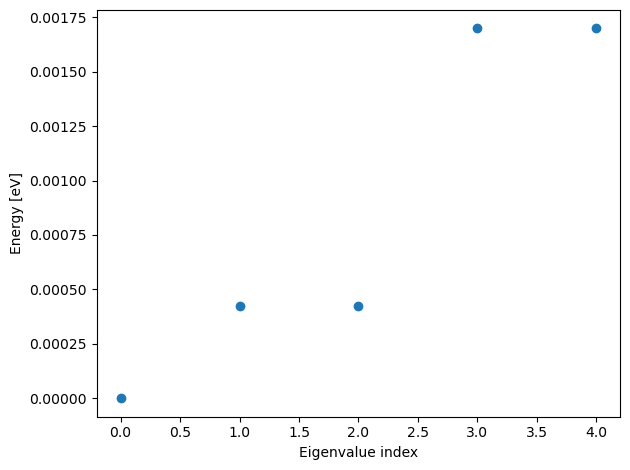

In [5]:
import scipy.linalg as lg
import numpy as np

es = lg.eigvalsh(H.todense()) # compute eigenvalues
es = es - es[0] ; es = es[es<0.1]
plt.scatter(range(len(es)),es) # plot eigenvalues
plt.xlabel("Eigenvalue index") ; plt.ylabel("Energy [eV]") ; plt.tight_layout()

# with the current parameters, this Hamiltonian describes a spin Hamiltonian like S111**2 for S=2